In [32]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt # Visualization

import sklearn
import statistics

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

import matplotlib.pyplot as plt

from sklearn.svm import SVR 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import cross_val_score

file_path = 'Cinemark_data_for_all_algorithms.csv'

df = pd.read_csv(file_path)

df.set_index('Date_Time', inplace=True)
df = df.drop('Unnamed: 0', axis = 1)
display(df)


,Facility_Demand_Rate_kW,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD01_Zone_Mean_Air_Temperature,AUD01_HTG_SETPT,AUD01_CLG_SETPT,AUD02_Zone_Mean_Air_Temperature,AUD02_HTG_SETPT,AUD02_CLG_SETPT,AUD03_Zone_Mean_Air_Temperature,AUD03_HTG_SETPT,...,PROJC_CLG_SETPT,PROJD_Zone_Mean_Air_Temperature,PROJD_HTG_SETPT,PROJD_CLG_SETPT,OFFICE_Zone_Mean_Air_Temperature,OFFICE_HTG_SETPT,OFFICE_CLG_SETPT,EMPLOYEE_Zone_Mean_Air_Temperature,EMPLOYEE_HTG_SETPT,EMPLOYEE_CLG_SETPT
Date_Time,,,,,,,,,,,,,,,,,,,,,
01/01 00:05:00,190.426026,6.7,20.475174,20.0,23.8889,20.480841,20.0,23.8889,20.243276,20.0,...,23.8889,20.001310,20.0,23.8889,20.338029,20.0,23.8889,20.001048,20.0,23.8889
01/01 00:10:00,190.360637,6.7,20.033642,20.0,23.8889,20.047459,20.0,23.8889,20.424724,20.0,...,23.8889,19.999363,20.0,23.8889,20.306129,20.0,23.8889,20.000008,20.0,23.8889
01/01 00:15:00,190.331229,6.7,20.489567,20.0,23.8889,20.478936,20.0,23.8889,20.003879,20.0,...,23.8889,20.489683,20.0,23.8889,20.275221,20.0,23.8889,20.479038,20.0,23.8889
01/01 00:20:00,190.456673,6.7,20.056314,20.0,23.8889,20.043813,20.0,23.8889,20.520028,20.0,...,23.8889,20.093437,20.0,23.8889,20.244951,20.0,23.8889,20.057682,20.0,23.8889
01/01 00:25:00,190.297697,6.7,20.473177,20.0,23.8889,20.477356,20.0,23.8889,20.153758,20.0,...,23.8889,20.001184,20.0,23.8889,20.215148,20.0,23.8889,20.488301,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12/31 23:40:00,190.877238,3.3,20.252889,20.0,23.8889,20.489481,20.0,23.8889,20.243799,20.0,...,23.8889,20.272905,20.0,23.8889,20.243910,20.0,23.8889,20.404130,20.0,23.8889
12/31 23:45:00,191.321030,3.3,20.244394,20.0,23.8889,20.006850,20.0,23.8889,20.244366,20.0,...,23.8889,20.244057,20.0,23.8889,20.508249,20.0,23.8889,20.006278,20.0,23.8889
12/31 23:50:00,190.905346,3.3,20.252896,20.0,23.8889,20.489467,20.0,23.8889,20.238186,20.0,...,23.8889,20.271679,20.0,23.8889,20.064467,20.0,23.8889,20.401844,20.0,23.8889


Finding the optimal parameters for the SVM algorithm on the whole dataset is long to compute. Therefore we can also use 1 room in the dataset and a month of july for the SVM.

In [33]:
# df_AUD1 = pd.DataFrame()

# # df_AUD1["Date/Time"]                                                                =   df["Date/Time"]

# df_AUD1["AUD01 HEAT COIL:Heating Coil NaturalGas Rate [W]"]                         =   df["AUD01 HEAT COIL:Heating Coil NaturalGas Rate [W](TimeStep)"] / 1000
# df_AUD1["AUD01 FAN:Fan Electricity Rate [W]"]                                       =   df["AUD01 FAN:Fan Electricity Rate [W](TimeStep)"] / 1000
# df_AUD1["AUD01 COOL COIL:Cooling Coil Electricity Rate [W]"]                        =   df["AUD01 COOL COIL:Cooling Coil Electricity Rate [W](TimeStep)"] / 1000

# df_AUD1['AUD01_Total_kW'] = df_AUD1["AUD01 HEAT COIL:Heating Coil NaturalGas Rate [W]"] + df_AUD1["AUD01 FAN:Fan Electricity Rate [W]"] + df_AUD1["AUD01 COOL COIL:Cooling Coil Electricity Rate [W]"]   

# df_AUD1.drop(columns=['AUD01 HEAT COIL:Heating Coil NaturalGas Rate [W]',
#                  'AUD01 FAN:Fan Electricity Rate [W]',
#                  'AUD01 COOL COIL:Cooling Coil Electricity Rate [W]'],
#         inplace=True)

# df_AUD1["Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)"]           =   df["Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)"] 
# df_AUD1["AUD01:Zone Mean Air Temperature [C](TimeStep)"]                            =   df["AUD01:Zone Mean Air Temperature [C](TimeStep)"]

# # df_AUD1["AUD01 HEAT COIL:Heating Coil Runtime Fraction"]                            =   df["AUD01 HEAT COIL:Heating Coil Runtime Fraction [](TimeStep)"]
# # df_AUD1["AUD01 COOL COIL:Cooling Coil Runtime Fraction [](TimeStep)"]               =   df["AUD01 COOL COIL:Cooling Coil Runtime Fraction [](TimeStep)"]
# # df_AUD1["AUD01 COOL COIL:Cooling Coil Stage 2 Runtime Fraction [](TimeStep)"]       =   df["AUD01 COOL COIL:Cooling Coil Stage 2 Runtime Fraction [](TimeStep)"]

# df_AUD1["AUD01 HTG SETPT SCH:Schedule Value [](TimeStep)"]                          =   df["AUD01 HTG SETPT SCH:Schedule Value [](TimeStep)"]
# df_AUD1["AUD01 CLG SETPT SCH:Schedule Value [](TimeStep)"]                          =   df["AUD01 CLG SETPT SCH:Schedule Value [](TimeStep)"]

# # df.set_index('Date/Time', inplace=True)

# display(df_AUD1)


In [34]:
# Total number of indices
total_indices = 105120

indices_per_month = 105120 / 12

# Calculate the starting and ending indices for July
july_start_index = int((7 - 1) * indices_per_month) - 432  # July start
july_end_index = (int(7 * indices_per_month) - 265)# July ends at the start of August (substract 4464 to get half of july)

# Print the range of indices corresponding to July
print("Range of indices corresponding to July:")
print("Start Index:", july_start_index)
print("End Index:", july_end_index - 1)  # Subtract 1 to get the index of the last interval in July

df_july = df.iloc[july_start_index:july_end_index + 1]

display(df_july)

Range of indices corresponding to July:
Start Index: 52128
End Index: 61054


,Facility_Demand_Rate_kW,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD01_Zone_Mean_Air_Temperature,AUD01_HTG_SETPT,AUD01_CLG_SETPT,AUD02_Zone_Mean_Air_Temperature,AUD02_HTG_SETPT,AUD02_CLG_SETPT,AUD03_Zone_Mean_Air_Temperature,AUD03_HTG_SETPT,...,PROJC_CLG_SETPT,PROJD_Zone_Mean_Air_Temperature,PROJD_HTG_SETPT,PROJD_CLG_SETPT,OFFICE_Zone_Mean_Air_Temperature,OFFICE_HTG_SETPT,OFFICE_CLG_SETPT,EMPLOYEE_Zone_Mean_Air_Temperature,EMPLOYEE_HTG_SETPT,EMPLOYEE_CLG_SETPT
Date_Time,,,,,,,,,,,,,,,,,,,,,
07/01 00:05:00,341.837389,27.666667,23.404173,20.0,23.8889,23.405025,20.0,23.8889,23.867110,20.0,...,23.8889,23.637088,20.0,23.8889,23.649240,20.0,23.8889,23.651261,20.0,23.8889
07/01 00:10:00,300.925644,27.633333,23.833317,20.0,23.8889,23.858557,20.0,23.8889,23.406637,20.0,...,23.8889,23.648161,20.0,23.8889,23.638057,20.0,23.8889,23.636074,20.0,23.8889
07/01 00:15:00,346.437052,27.600000,23.404102,20.0,23.8889,23.404933,20.0,23.8889,23.864918,20.0,...,23.8889,23.637131,20.0,23.8889,23.485196,20.0,23.8889,23.400437,20.0,23.8889
07/01 00:20:00,295.422629,27.566667,23.831350,20.0,23.8889,23.856343,20.0,23.8889,23.406551,20.0,...,23.8889,23.648149,20.0,23.8889,23.649437,20.0,23.8889,23.651407,20.0,23.8889
07/01 00:25:00,343.426935,27.533333,23.404035,20.0,23.8889,23.404857,20.0,23.8889,23.862572,20.0,...,23.8889,23.637190,20.0,23.8889,23.638020,20.0,23.8889,23.636157,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
07/31 23:40:00,333.681265,27.833333,23.851430,20.0,23.8889,23.405977,20.0,23.8889,23.648244,20.0,...,23.8889,23.636703,20.0,23.8889,23.637731,20.0,23.8889,23.635547,20.0,23.8889
07/31 23:45:00,337.643036,27.750000,23.404925,20.0,23.8889,23.876170,20.0,23.8889,23.638710,20.0,...,23.8889,23.648519,20.0,23.8889,23.520685,20.0,23.8889,23.400629,20.0,23.8889
07/31 23:50:00,339.961087,27.666667,23.847841,20.0,23.8889,23.405869,20.0,23.8889,23.648232,20.0,...,23.8889,23.636807,20.0,23.8889,23.648577,20.0,23.8889,23.650795,20.0,23.8889


In [35]:
x = df_july.drop('Facility_Demand_Rate_kW',axis = 1) 
y = df_july.Facility_Demand_Rate_kW	

#split into training, testing data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

scaler = StandardScaler()
Fit = scaler.fit(x_train)

X_train_scaled = Fit.transform(x_train)
X_test_scaled = Fit.transform(x_test)

# Cross Validation
# Input parameters ranges to cross validation 
gamma_range = [0.1, 0.01, 0.001, 0.0001]
epsilon_range = [x * 0.1 for x in range(0, 2)]
C_range = range(1, 2500, 500)

tuned_parameters = [{
    'kernel': ['rbf'],
    'C': C_range,
    'gamma': gamma_range,
    'epsilon': epsilon_range}]

#Search for best parameters w/ cross validation
svr = GridSearchCV(SVR(C=2000, gamma=0.01), param_grid = tuned_parameters, verbose = 0)

modelSVR = svr.fit(X_train_scaled, np.ravel(y_train))

print(svr.best_params_)

{'C': 2001, 'epsilon': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}


In [36]:
# predict
y_predict = modelSVR.predict(X_test_scaled)

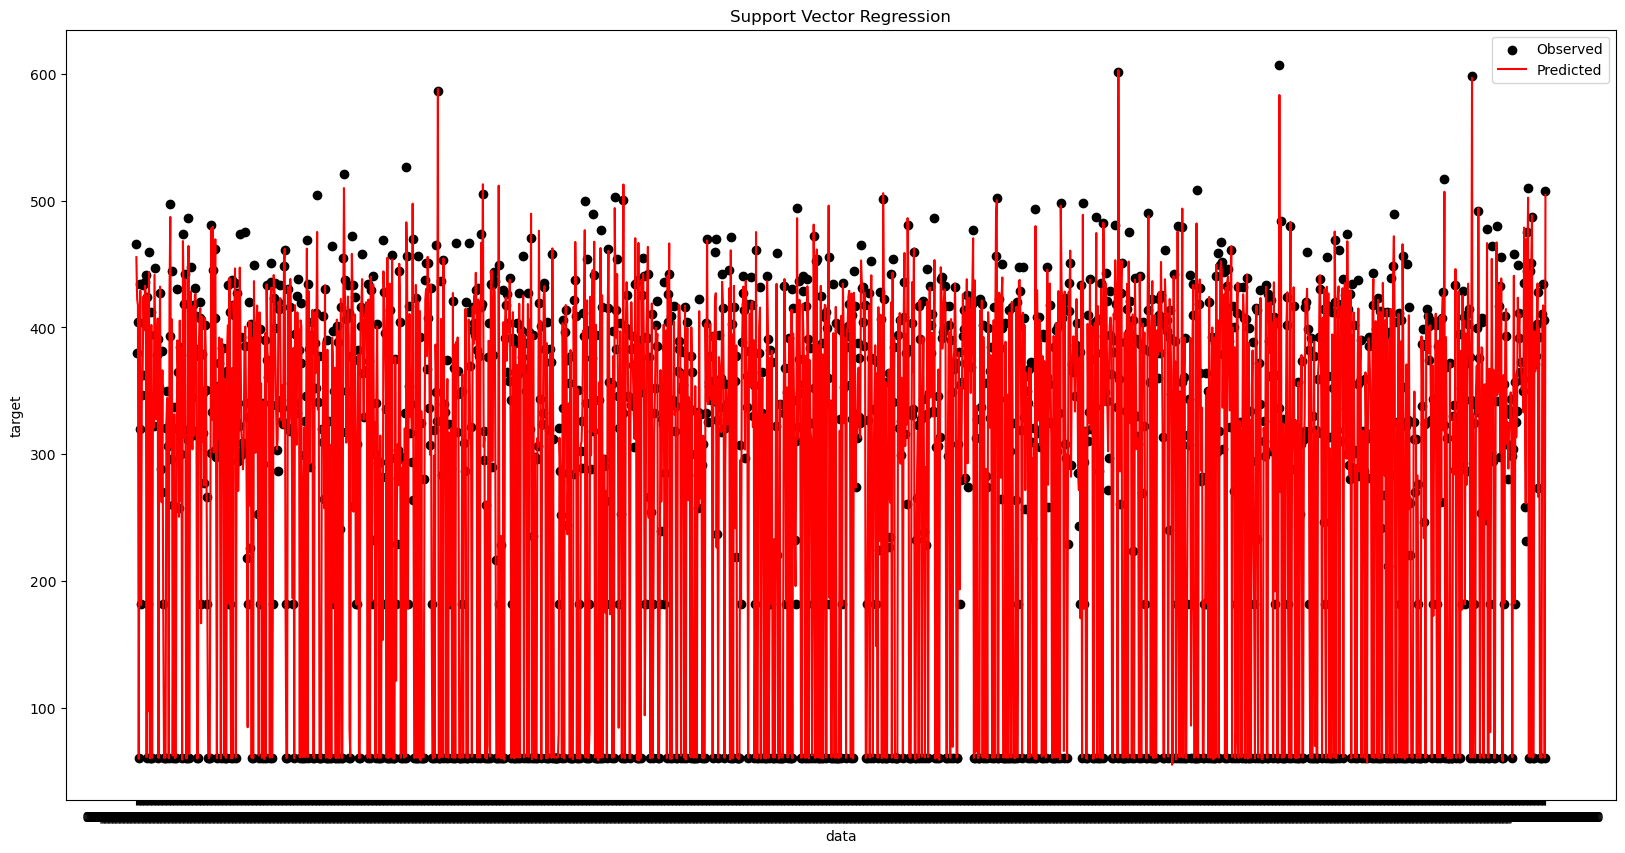

Text(0.5, 1.0, 'Predicted vs Actual Energy Use: $Y_i$ vs $\\hat{Y}_i$')

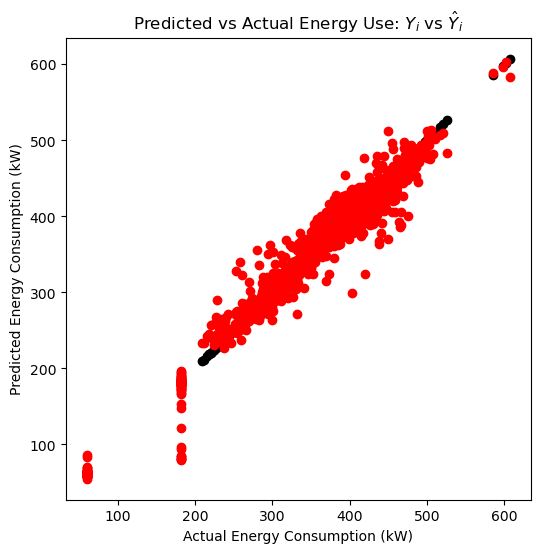

In [37]:
# Visualize Data
# Plot observed and predicted energy values (actual data points vs svm)
fig,ax = plt.subplots(1, 1,figsize=(20,10))
plt.scatter(x_test.index, y_test, c='k', label='Observed')
plt.plot(x_test.index, y_predict, c='r', label='Predicted')
plt.xlabel('data')
plt.ylabel('target')
plt.title('Support Vector Regression')
plt.legend()
plt.show()

# Plot Observed vs Predicted (line of best fit chart)
fig = plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, c='k')
plt.scatter(y_test, y_predict, c='r')
plt.xlabel('Actual Energy Consumption (kW)')
plt.ylabel("Predicted Energy Consumption (kW)")
plt.title("Predicted vs Actual Energy Use: $Y_i$ vs $\hat{Y}_i$")

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
# Error Evaluation 
# Training error 

# print("Train Data")
# print("R^2:", r2_score(y_train, y_predict_train))
# print("MSE:", mean_squared_error(y_train, y_predict_train))
# print("Root MSE:", np.sqrt(mean_squared_error(y_train, y_predict_train)))
# print("MAE:", mean_absolute_error(y_train, y_predict_train))
# print("MAPE: %", mean_absolute_percentage_error(y_train ,y_predict_train))

# print(" ")

# Test Error
print("Test Data")
print("R^2:", r2_score(y_test, y_predict))
print("MSE:", mean_squared_error(y_test, y_predict))
print("Root MSE:", np.sqrt(mean_squared_error(y_test, y_predict)))
print("MAE:", mean_absolute_error(y_test, y_predict))
print("MAPE: %", mean_absolute_percentage_error(y_test, y_predict))

Test Data
R^2: 0.9880895853046804
MSE: 265.79030392246943
Root MSE: 16.303076517101594
MAE: 9.067075802997232
MAPE: % 0.029383714578155546
